Roll No : 24BAD116
Name    : SUBASRI R


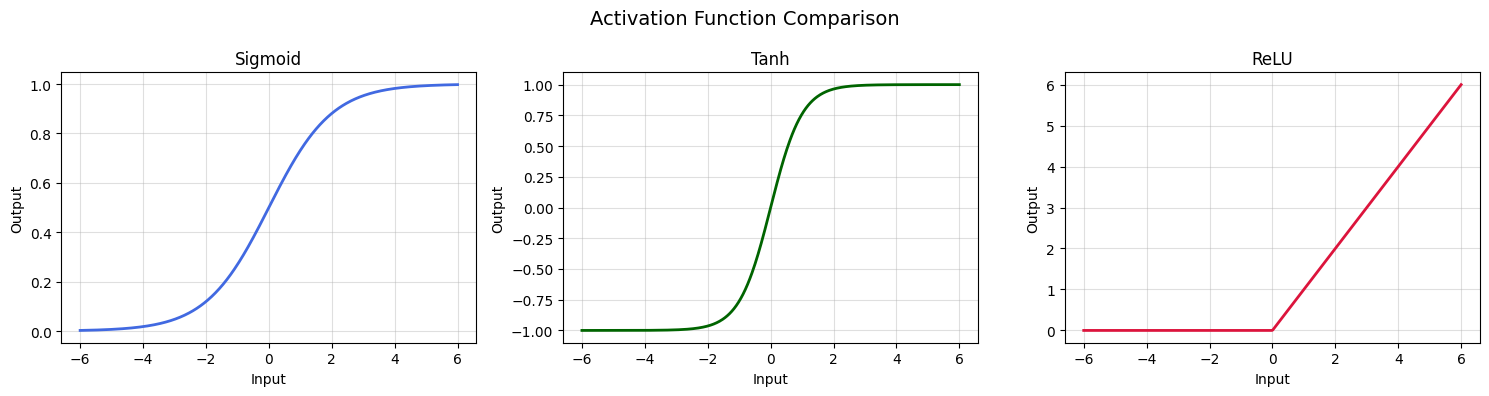

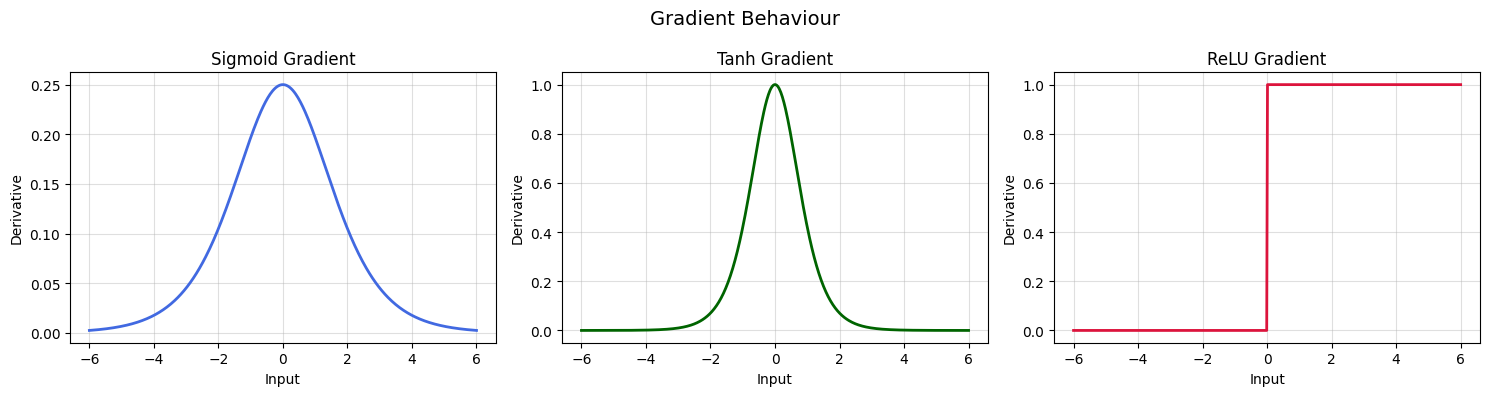



Function    Range          Saturation          Cost              Typical Usage
Sigmoid     (0,1)          Both Ends           High              Binary Classification
Tanh        (-1,1)         Both Ends           High              Hidden Layers
ReLU        [0,∞)          Negative Side       Low               Deep Networks


In [ ]:
# EXPERIMENT 2 - PART A

print("Roll No : 24BAD116")
print("Name    : SUBASRI R")

import numpy as np
import matplotlib.pyplot as plt

values = np.linspace(-6, 6, 500)

activation_functions = {
    "Sigmoid": lambda x: 1 / (1 + np.exp(-x)),
    "Tanh": np.tanh,
    "ReLU": lambda x: np.maximum(0, x)
}

def derivative(name, x):
    if name == "Sigmoid":
        y = activation_functions[name](x)
        return y * (1 - y)

    elif name == "Tanh":
        return 1 - np.tanh(x)**2

    elif name == "ReLU":
        return np.where(x > 0, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

colors = ["royalblue", "darkgreen", "crimson"]

for ax, (name, func), color in zip(
        axes,
        activation_functions.items(),
        colors):

    ax.plot(values, func(values), color=color, linewidth=2)

    ax.set_title(name)

    ax.set_xlabel("Input")

    ax.set_ylabel("Output")

    ax.grid(alpha=0.4)

plt.suptitle("Activation Function Comparison", fontsize=14)

plt.tight_layout()

plt.show()

fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, name, color in zip(
        axes,
        activation_functions.keys(),
        colors):

    ax.plot(
        values,
        derivative(name, values),
        color=color,
        linewidth=2
    )

    ax.set_title(f"{name} Gradient")

    ax.set_xlabel("Input")

    ax.set_ylabel("Derivative")

    ax.grid(alpha=0.4)

plt.suptitle("Gradient Behaviour", fontsize=14)

plt.tight_layout()

plt.show()


summary = [
    ["Sigmoid","(0,1)","Both Ends","High","Binary Classification"],
    ["Tanh","(-1,1)","Both Ends","High","Hidden Layers"],
    ["ReLU","[0,∞)","Negative Side","Low","Deep Networks"]
]

print("\n")
print("="*85)
print("{:<12}{:<15}{:<20}{:<18}{}".format(
    "Function",
    "Range",
    "Saturation",
    "Cost",
    "Typical Usage"))
print("="*85)

for row in summary:
    print("{:<12}{:<15}{:<20}{:<18}{}".format(*row))

print("="*85)

Roll No : 24BAD116
Name    : SUBASRI R

Training Model using SIGMOID Activation

Training Model using TANH Activation

Training Model using RELU Activation


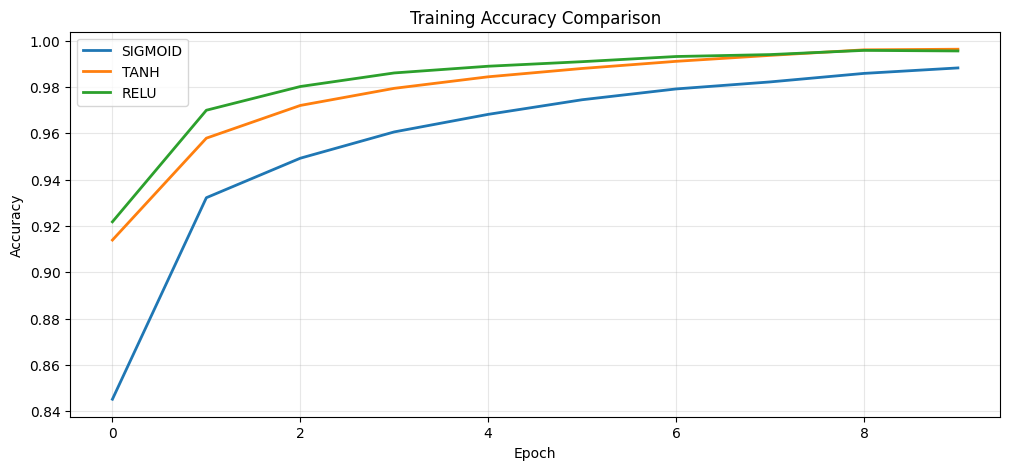

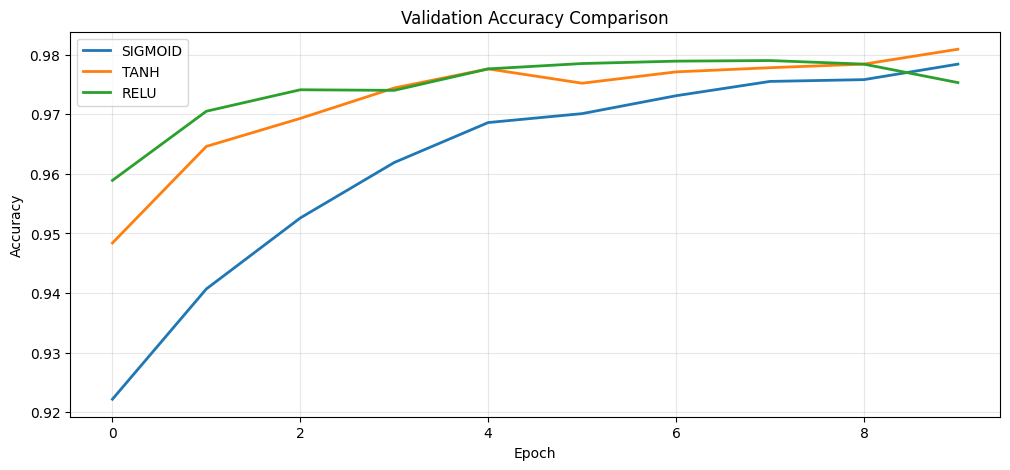

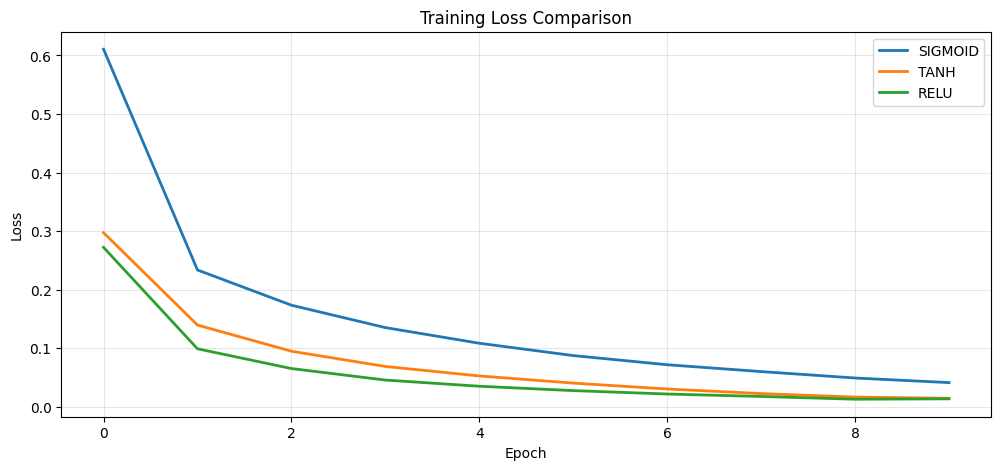

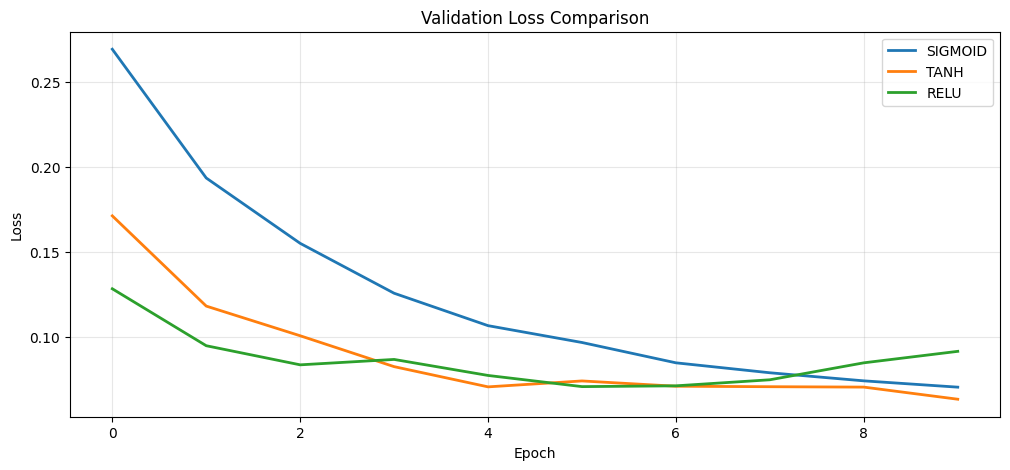



Activation  Train Acc         Val Acc           Train Loss        Val Loss          
SIGMOID     0.9883            0.9784            0.0412            0.0705            
TANH        0.9964            0.9809            0.0144            0.0634            
RELU        0.9956            0.9753            0.0134            0.0915            

Best Activation Function : TANH


In [ ]:
# EXPERIMENT 2 - PART B

print("Roll No : 24BAD116")
print("Name    : SUBASRI R")

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

def create_model(activation):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(784,)),

        tf.keras.layers.Dense(256, activation=activation),

        tf.keras.layers.Dense(128, activation=activation),

        tf.keras.layers.Dense(10, activation="softmax")

    ])

    model.compile(

        optimizer="adam",

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

activation_list = ["sigmoid", "tanh", "relu"]

training_history = {}

for act in activation_list:

    print(f"\nTraining Model using {act.upper()} Activation")

    ann = create_model(act)

    history = ann.fit(

        x_train,

        y_train,

        validation_data=(x_test, y_test),

        epochs=10,

        batch_size=128,

        verbose=0

    )

    training_history[act] = history.history

plt.figure(figsize=(12,5))

for act in activation_list:

    plt.plot(

        training_history[act]["accuracy"],

        linewidth=2,

        label=f"{act.upper()}"

    )

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

plt.figure(figsize=(12,5))

for act in activation_list:

    plt.plot(

        training_history[act]["val_accuracy"],

        linewidth=2,

        label=f"{act.upper()}"

    )

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

plt.figure(figsize=(12,5))

for act in activation_list:

    plt.plot(

        training_history[act]["loss"],

        linewidth=2,

        label=f"{act.upper()}"

    )

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.show()


plt.figure(figsize=(12,5))

for act in activation_list:

    plt.plot(

        training_history[act]["val_loss"],

        linewidth=2,

        label=f"{act.upper()}"

    )

plt.title("Validation Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

print("\n")
print("=" * 90)
print("{:<12}{:<18}{:<18}{:<18}{:<18}".format(
    "Activation",
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss"
))
print("=" * 90)

for act in activation_list:

    train_acc = training_history[act]["accuracy"][-1]
    val_acc = training_history[act]["val_accuracy"][-1]
    train_loss = training_history[act]["loss"][-1]
    val_loss = training_history[act]["val_loss"][-1]

    print("{:<12}{:<18.4f}{:<18.4f}{:<18.4f}{:<18.4f}".format(
        act.upper(),
        train_acc,
        val_acc,
        train_loss,
        val_loss
    ))

print("=" * 90)

best = max(
    activation_list,
    key=lambda x: training_history[x]["val_accuracy"][-1]
)

print(f"\nBest Activation Function : {best.upper()}")

Roll No : 24BAD116
Name    : SUBASRI R

Training using SGD

Training using Momentum

Training using RMSProp

Training using Adam


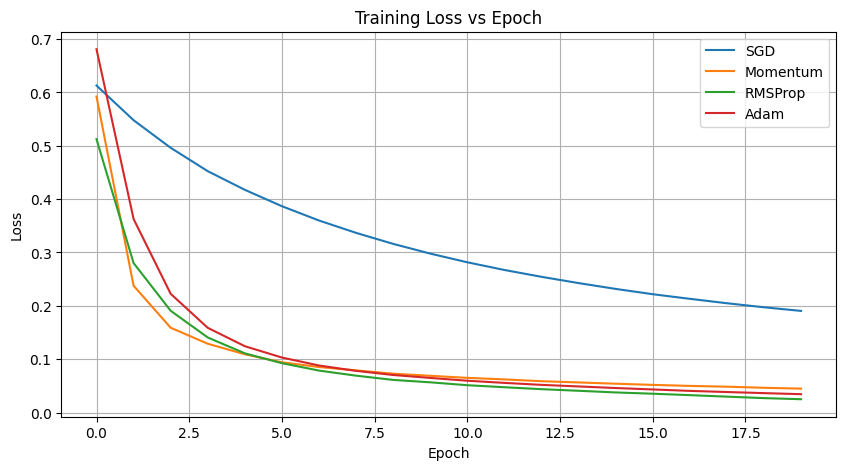

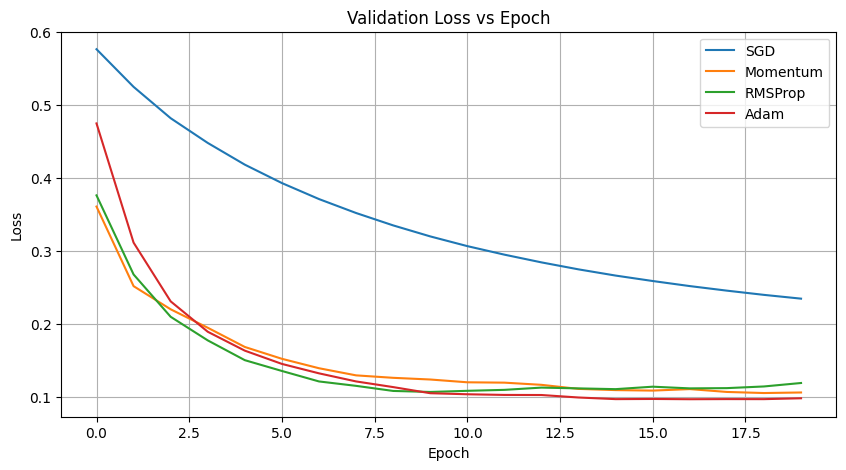

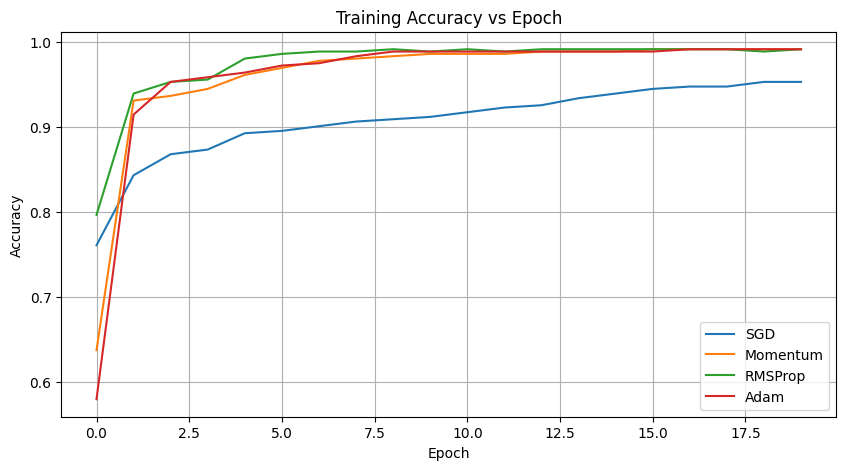

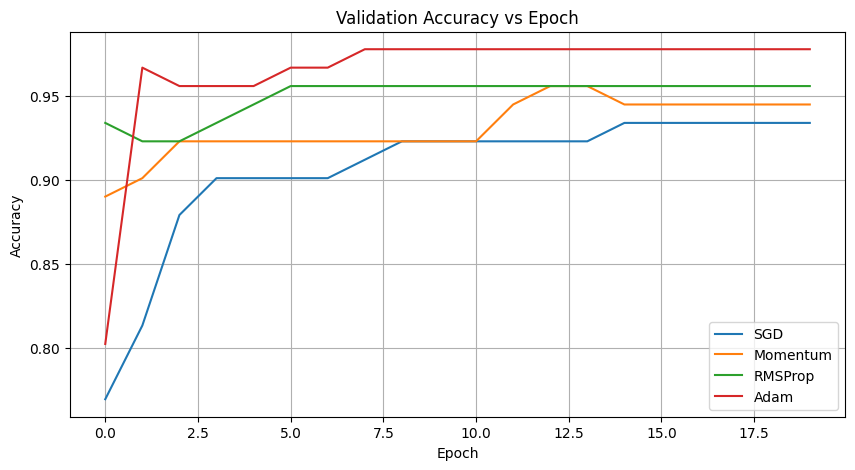


Final Comparison
Optimizer   Train Acc         Val Acc           Train Loss        Val Loss          
SGD         0.9533            0.9341            0.1905            0.2343            
Momentum    0.9918            0.9451            0.0449            0.1057            
RMSProp     0.9918            0.9560            0.0250            0.1187            
Adam        0.9918            0.9780            0.0345            0.0977            


In [ ]:
# EXPERIMENT 2 - PART C
print("Roll No : 24BAD116")
print("Name    : SUBASRI R")

import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=11
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to Build ANN

def build_network(optimizer_object):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(30,)),

        tf.keras.layers.Dense(64, activation="relu"),

        tf.keras.layers.Dense(32, activation="relu"),

        tf.keras.layers.Dense(1, activation="sigmoid")

    ])

    model.compile(

        optimizer=optimizer_object,

        loss="binary_crossentropy",

        metrics=["accuracy"]

    )

    return model

# Optimizers

optimizer_dict = {

    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),

    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)

}

history_data = {}

# Train Models
for name, optimizer in optimizer_dict.items():

    print(f"\nTraining using {name}")

    network = build_network(optimizer)

    history = network.fit(

        X_train,

        y_train,

        validation_split=0.20,

        epochs=20,

        batch_size=32,

        verbose=0

    )

    history_data[name] = history.history

# Plot Training Loss
plt.figure(figsize=(10,5))

for name in history_data:

    plt.plot(
        history_data[name]["loss"],
        label=name
    )

plt.title("Training Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.legend()

plt.show()

# Plot Validation Loss
plt.figure(figsize=(10,5))

for name in history_data:

    plt.plot(
        history_data[name]["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.legend()

plt.show()

# Plot Training Accuracy
plt.figure(figsize=(10,5))

for name in history_data:

    plt.plot(
        history_data[name]["accuracy"],
        label=name
    )

plt.title("Training Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.legend()

plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10,5))

for name in history_data:

    plt.plot(
        history_data[name]["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid()

plt.legend()

plt.show()

# Final Comparison Table
print("\nFinal Comparison")
print("=" * 80)

print("{:<12}{:<18}{:<18}{:<18}{:<18}".format(
    "Optimizer",
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss"
))

print("=" * 80)

for name in history_data:

    train_acc = history_data[name]["accuracy"][-1]
    val_acc = history_data[name]["val_accuracy"][-1]
    train_loss = history_data[name]["loss"][-1]
    val_loss = history_data[name]["val_loss"][-1]

    print("{:<12}{:<18.4f}{:<18.4f}{:<18.4f}{:<18.4f}".format(
        name,
        train_acc,
        val_acc,
        train_loss,
        val_loss
    ))

print("=" * 80)

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [9]:
print("Roll No : 24BAD116")
print("Name    : SUBASRI R")

import tensorflow as tf
import numpy as np
import os

os.makedirs("Experiment2", exist_ok=True)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

X = np.random.rand(100, 10)
Y = np.random.rand(100, 1)

model.fit(
    X,
    Y,
    epochs=3,
    verbose=1
)

model.save("Experiment2/ANN_Model.keras")

print("\nModel Saved Successfully")

readme = """
# Deep Learning Lab

## Experiment 2

### Objective
Study activation functions and optimization algorithms.

### Software
Python
TensorFlow
Google Colab
GitHub

### Tasks
1. Visualized Activation Functions
2. Compared Sigmoid, Tanh and ReLU
3. Compared SGD, Momentum, RMSProp and Adam
4. Saved trained ANN model
5. Maintained experiment documentation
"""

with open("Experiment2/README.md", "w") as file:
    file.write(readme)

print("README Created Successfully")

with open("Experiment2/Experiment_Notes.txt", "w") as file:
    file.write("Experiment 2 Completed Successfully\n")
    file.write("ANN model trained successfully.\n")
    file.write("Activation functions and optimizers analysed.\n")

print("Notes File Created Successfully")

print("\nFiles Generated")
print("1. ANN_Model.keras")
print("2. README.md")
print("3. Experiment_Notes.txt")

Roll No : 24BAD116
Name    : SUBASRI R
Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3507
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3170
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2908

Model Saved Successfully
README Created Successfully
Notes File Created Successfully

Files Generated
1. ANN_Model.keras
2. README.md
3. Experiment_Notes.txt
